# Tercera sesión TFG - Estudio de la asimetría, *función Fases de la Luna*

En esta última parte, la idea es estudiar la asimetría que hay entre los polos norte y sur de los distintos mapas de CMB que hemos contemplado.

Definimos la *Asimetría* matemáticamente como:

$$
    \text{Asimetría} \equiv A = \frac{\sigma_N^2-\sigma_S^2}{\sigma_{\text{Total}}^2}
$$

donde $\sigma_i^2$ es la varianza del hemisferio $i$.

In [1]:
# Carga de paquetes necesarios
import healpy as hp
import numpy as np
import scipy.stats as scs
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import FUNCIONES as FP
importlib.reload(FP)

<module 'FUNCIONES' from '/mnt/c/Users/Ariteirata/Documents/Grado - Física/Cosmología TFG/Notebooks/FUNCIONES.py'>

In [2]:
# Especificamos la máscara que vamos a usar
mask_P = hp.read_map('Mapas/MASK_CMB_POLARIZATION_2018.fits').astype(np.bool_)
mask_T = hp.read_map('Mapas/MASK_CMB_TEMPERATURE_2018.fits').astype(np.bool_)

El mapa que vamos a estudiar primero es SMICA (**Spectral Matching Independent Component Analysis**), ya que comparado con los demás mapas, es el que más cerca de los datos originales está tras aplicar la máscara. 

Cargamos pues este mapa:

In [3]:
ruta_smica = 'Mapas/SMICA_2018.fits'
mT, mQ, mU = hp.read_map(ruta_smica, field = (0, 1, 2), nest = True) *1e6
NSIDE = hp.get_nside(mT)
print(NSIDE)

2048


Vamos ahora a hacer uso de partes de la función `FP.PARCHES` para hacer una nueva función llamada `ASIMETRIA` que aplicará una máscara dependiendo de si queremos obtener el hemisferio norte o el sur y posteriormente obtendrá la varianza de cada hemisferio así como la total para poder calcular la asimetría.

In [5]:
def ASIMETRIA_NS(mapa, mask_gal, nside):
    'Calcula la asimetría entre dos hemisferios de un mapa de CMB'
    
    # Obtenemos los ángulos esféricos (theta: colatitud, phi: longitud) de cada píxel
    npix = hp.nside2npix(2048)
    theta, phi = hp.pix2ang(2048, np.arange(npix))

    # Aplicamos las máscaras de hemisferio
    MN = np.ones(npix, dtype=bool)        # Array de unos con el mismo tamaño que el mapa
    MN[theta < np.pi/2] = 0               # Array donde si se cumple la condición, ese punto pasa de 1 a 0

    MS = np.ones(npix, dtype=bool)        # Array de unos con el mismo tamaño que el mapa
    MS[theta > np.pi/2] = 0               # Array donde si se cumple la condición, ese punto pasa de 1 a 0

    # Si hemos especificado la máscara galáctica, la juntamos con las máscaras de los 
    # distintos hemisferios
    if mask_gal is not None:
        MN = np.logical_not(mask_gal) | MN
        MS = np.logical_not(mask_gal) | MS

    # Cargamos ahora un mapa para cada hemisferio y le aplicamos
    # la correspondiente máscara
    mapa_norte = hp.ma(mapa)              
    mapa_norte.mask = MN     
    mapa_norte_ajustado = hp.ud_grade(mapa_norte, nside) 
    
    mapa_sur = hp.ma(mapa)                
    mapa_sur.mask = MS   
    mapa_sur_ajustado = hp.ud_grade(mapa_sur, nside)

    mapa_total = hp.ma(mapa)
    mapa_total.mask = np.logical_not(mask_gal)
    mapa_total_ajustado = hp.ud_grade(mapa_total, nside)

    # Lo siguiente es obtener las varianzas de los tres mapas: norte, sur y total
    
    sigma_norte = np.var(mapa_norte_ajustado.compressed())    # Añadimos .compressed() para eliminar puntos enmascarados
    sigma_sur = np.var(mapa_sur_ajustado.compressed())
    sigma_total = np.var(mapa_total_ajustado.compressed())                 
    
    # Finalmente escribimos la expresión de la asimetría
    asimetria = (sigma_norte - sigma_sur)/sigma_total

    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - #
    return asimetria

Una vez creada la función, la aplicamos a los tres mapas que tenemos de SMICA, obteniendo así la asimetría respecto al norte y sur polar.

In [6]:
nside_asim = 2048
asimetria_mT = ASIMETRIA_NS(mT, mask_T, nside_asim)
asimetria_mQ = ASIMETRIA_NS(mQ, mask_P, nside_asim)
asimetria_mU = ASIMETRIA_NS(mU, mask_P, nside_asim)

datos_asimetria = {
    'Mapa' : [f'SMICA_T - {nside_asim}', f'SMICA_Q - {nside_asim}', f'SMICA_U - {nside_asim}'],
    'Asimetría': [f'{asimetria_mT}', f'{asimetria_mQ}', f'{asimetria_mU}']
}

datos_asimetria = pd.DataFrame(datos_asimetria)
datos_asimetria

,Mapa,Asimetría
0,SMICA_T - 2048,-0.0586390495300293
1,SMICA_Q - 2048,0.08501381427049637
2,SMICA_U - 2048,0.09150563180446625


---

El siguiente paso sería obtener una función que nos permita obtener la asimetría entre distintos pares norte-sur, es decir, una función `FASES_LUNA` que irá variando los ángulos $\theta$ y $phi$ de forma que obtendremos distintos planos del CMB. Posteriormente, para cada uno de estos pares norte-sur generados obtendremos la asimetría y los planos para los que la asimetría es máxima (ya sea positiva o negativa)

In [6]:
def FASES_LUNA(mapa, mask_gal, sub_theta, sub_phi, nside, mostrar = True):
    'Obtiene diversos planos que dividen en dos el mapa de CMB.'
    'Calcula la asimetría entre dos hemisferios de este mapa, para cada plano.'

    # Aplicamos la máscara al mapa (si está definida).
    mapa_cargado = hp.ma(mapa)
    if mask_gal is not None:
        mapa_cargado.mask = np.logical_not(mask_gal)

    if nside is not None:
        mapa_ajustado = hp.ud_grade(mapa_cargado, nside) 

    else:
        mapa_ajustado = mapa_cargado
      
    # Obtenemos los ángulos esféricos (theta: colatitud, phi: longitud) de cada píxel.
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    # Lo siguiente es hacer las divisiones de theta y phi para los planos:
    cos_theta = np.linspace(0, 1, sub_theta, endpoint = False)
    phi_prima = np.linspace(0, 2*np.pi, sub_phi, endpoint = False)

    # Generamos ahora una variable que contendrá los vectores normales de los planos
    # Asimismo, añadimos manualmente el plano z = 0 para que no esté evaluado
    # multiples veces.
    planos = [[0.0, 0.0, 1.0]]
    theta_plano = [0]
    phi_plano = [0]

    for i in range(len(phi_prima)):
        for j in range(len(cos_theta)):
        
            x = np.sqrt(1 - cos_theta[j]**2) * np.cos(phi_prima[i])
            y = np.sqrt(1 - cos_theta[j]**2) * np.sin(phi_prima[i])
            z = cos_theta[j]
    
            planos.append([x, y, z])

            # Para que la función nos devuelva los datos de theta y phi pasaremos el coseno de theta
            # a theta usando el arccos, así como phi a grados también. De esta forma, obtendremos
            # directamente los valores de theta y phi para los que la asietría es máxima.
            theta_plano.append(np.degrees(np.arccos(cos_theta[j])))
            phi_plano.append(np.degrees(phi_prima[i]))

    # Generamos entonces el array con estos vectores normales.
    n = np.array(planos)

    # Una vez obtenidos los vectores de los planos, obtenemos los vectores
    # de posición r tal que al hacer el producto escalar de dichos vectores
    # con los del plano obtendremos si estamos situados en el "norte" o el 
    # "sur".
    r = np.column_stack([np.sin(theta) * np.cos(phi),
                         np.sin(theta) * np.sin(phi),
                         np.cos(theta)])

    # Para evitar usar .compressed() todo el rato, vamos a 
    # seleccionar directamente qué pixeles son válidos tras aplicar
    # la máscara. De esta forma los cálculos son más rápidos.
    if mask_gal is not None:
        mapa_valido = mapa_ajustado.data[np.logical_not(mapa_ajustado.mask)]
        r = r[np.logical_not(mapa_ajustado.mask), :]
    else:
        mapa_valido = mapa_ajustado.data

    sigma_total = np.var(mapa_valido) 

    asimetria = []
    
    # Hacemos el producto escalar plano por plano dentro del bucle
    for j in range(len(n)):
        # Multiplicamos escalarmente todos los puntos de la esfera por el vector
        # del plano en cuestión. De esta forma obtenemos los puntos que pertenecerán
        # al norte, y los que pertenecerán al sur.
        prod_escalar = r @ n[j, :]

        # Los puntos correspondientes al "norte" serán aquellos que apunten en la misma
        # dirección que el vector del plano (r * n > 0).
        norte = (prod_escalar > 0)

        # Los puntos correspondientes al "sur" serán aquellos que apunten dirección
        # contraria al vector del plano (r * n < 0). También podemos verlo como los puntos
        # que no pertenecen al norte.
        sur = ~norte

        # Para cada plano, obtenemos la varianza de su "norte" y de su "sur".
        sigma_norte = np.var(mapa_valido[norte])
        sigma_sur = np.var(mapa_valido[sur])

        A = (sigma_norte - sigma_sur) / sigma_total

        asimetria.append(A)

    # Escogemos finalmente los cinco planos que contienen el máximo de asimetría. Para ello
    # Ordenamos el array de asimetría y tomamos los cinco úlimos elementos (correspondientes
    # a los máximos en valor absoluto)
    i_top5 = np.argsort(np.abs(asimetria))[-5:]

    if mostrar:

        # Si elegimos la opción de mostrar, queremos dibujar en una cuadrícula para cada par phi-theta
        # El plano que estamos considerando. Para ello, obtenemos el rango de filas y columnas teniendo en
        # cuenta que hay que añadir una columna extra debido al plano z = 0.
        columnas = len(phi_prima) + 1         
        filas = len(cos_theta)
        
        fig = plt.figure(figsize=(3.5 * columnas, 2.5 * filas))

        # Para cada theta (fila), obtenemos el mapa recorriendo cada phi (columna).
        for i in range(filas):
            for j in range(columnas):
                
                # Posición del subgráfico en Matplotlib (empieza en 1).
                posicion = i * columnas + j + 1
                
                if j == 0:
                    # La primera columna corresponde al plano z = 0 ([0, 0, 1])
                    # Solo lo pintamos en la primera fila (i=0) para que no se repita abajo.
                    if i == 0:
                        i_plano = 0
                        theta_p = 0.0
                        phi_p = 0.0
                    else:
                        continue
                else:
                    # Si no se trata del primer plano, obtenemos su theta y su phi en grados.
                    i_plano = 1 + (j - 1) * len(cos_theta) + i
                    theta_p = np.degrees(np.arccos(cos_theta[i]))
                    phi_p = np.degrees(phi_prima[j - 1])
                
                n_actual = n[i_plano]
                A_actual = asimetria[i_plano]
                
                # Realizamos nuevamente el producto escalar para obtener la posición de los hemisferios
                prod_escalar = r @ n_actual

                # Generamos un mapa completamente vacío, donde si se cumple la condición de que el producto
                # escalar sea mayor que cero, lo rellenaremos de 1. En caso contrario (hemisferio sur) lo 
                # rellenaremos de -1.
                mapa_visual = np.full(npix, np.nan)
                valores_hemisferio = np.where(prod_escalar > 0, 1, -1)

                
                if mask_gal is not None:
                    # Si la máscara del plano galáctico ha sido añadida a la función, la vamos a dejar tal cual
                    # De esta forma, los puntos que no pertenezcan a la máscara serán los que pintemos.
                    mapa_visual[np.logical_not(mapa_ajustado.mask)] = valores_hemisferio
                else:
                    # Si no hemos añadido la máscara del plano galáctico, el mapa visual se pinta completamente
                    # con los puntos del hemisferio norte y sur, sin eliminar ninguno.
                    mapa_visual = valores_hemisferio
                
                # Si el plano está entre los cinco con más asimetría, usamos un color verdoso, si no rojizo.
                mapa_color = "Pastel2" if i_plano in i_top5 else "Pastel1"
                
                # Finalmente pintamos los mapas.
                hp.mollview(mapa_visual, 
                            sub=(filas, columnas, posicion),
                            title=f"θ={theta_p:.0f}°, φ={phi_p:.0f}°\nA={A_actual:.5f}",
                            cmap=mapa_color,        
                            cbar=False,        
                            notext=True)       
                
        plt.tight_layout()
        plt.show()

    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - #       
    return np.array(asimetria)[i_top5], np.array(theta_plano)[i_top5], np.array(phi_plano)[i_top5]

/tmp/ipykernel_632/2402681874.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


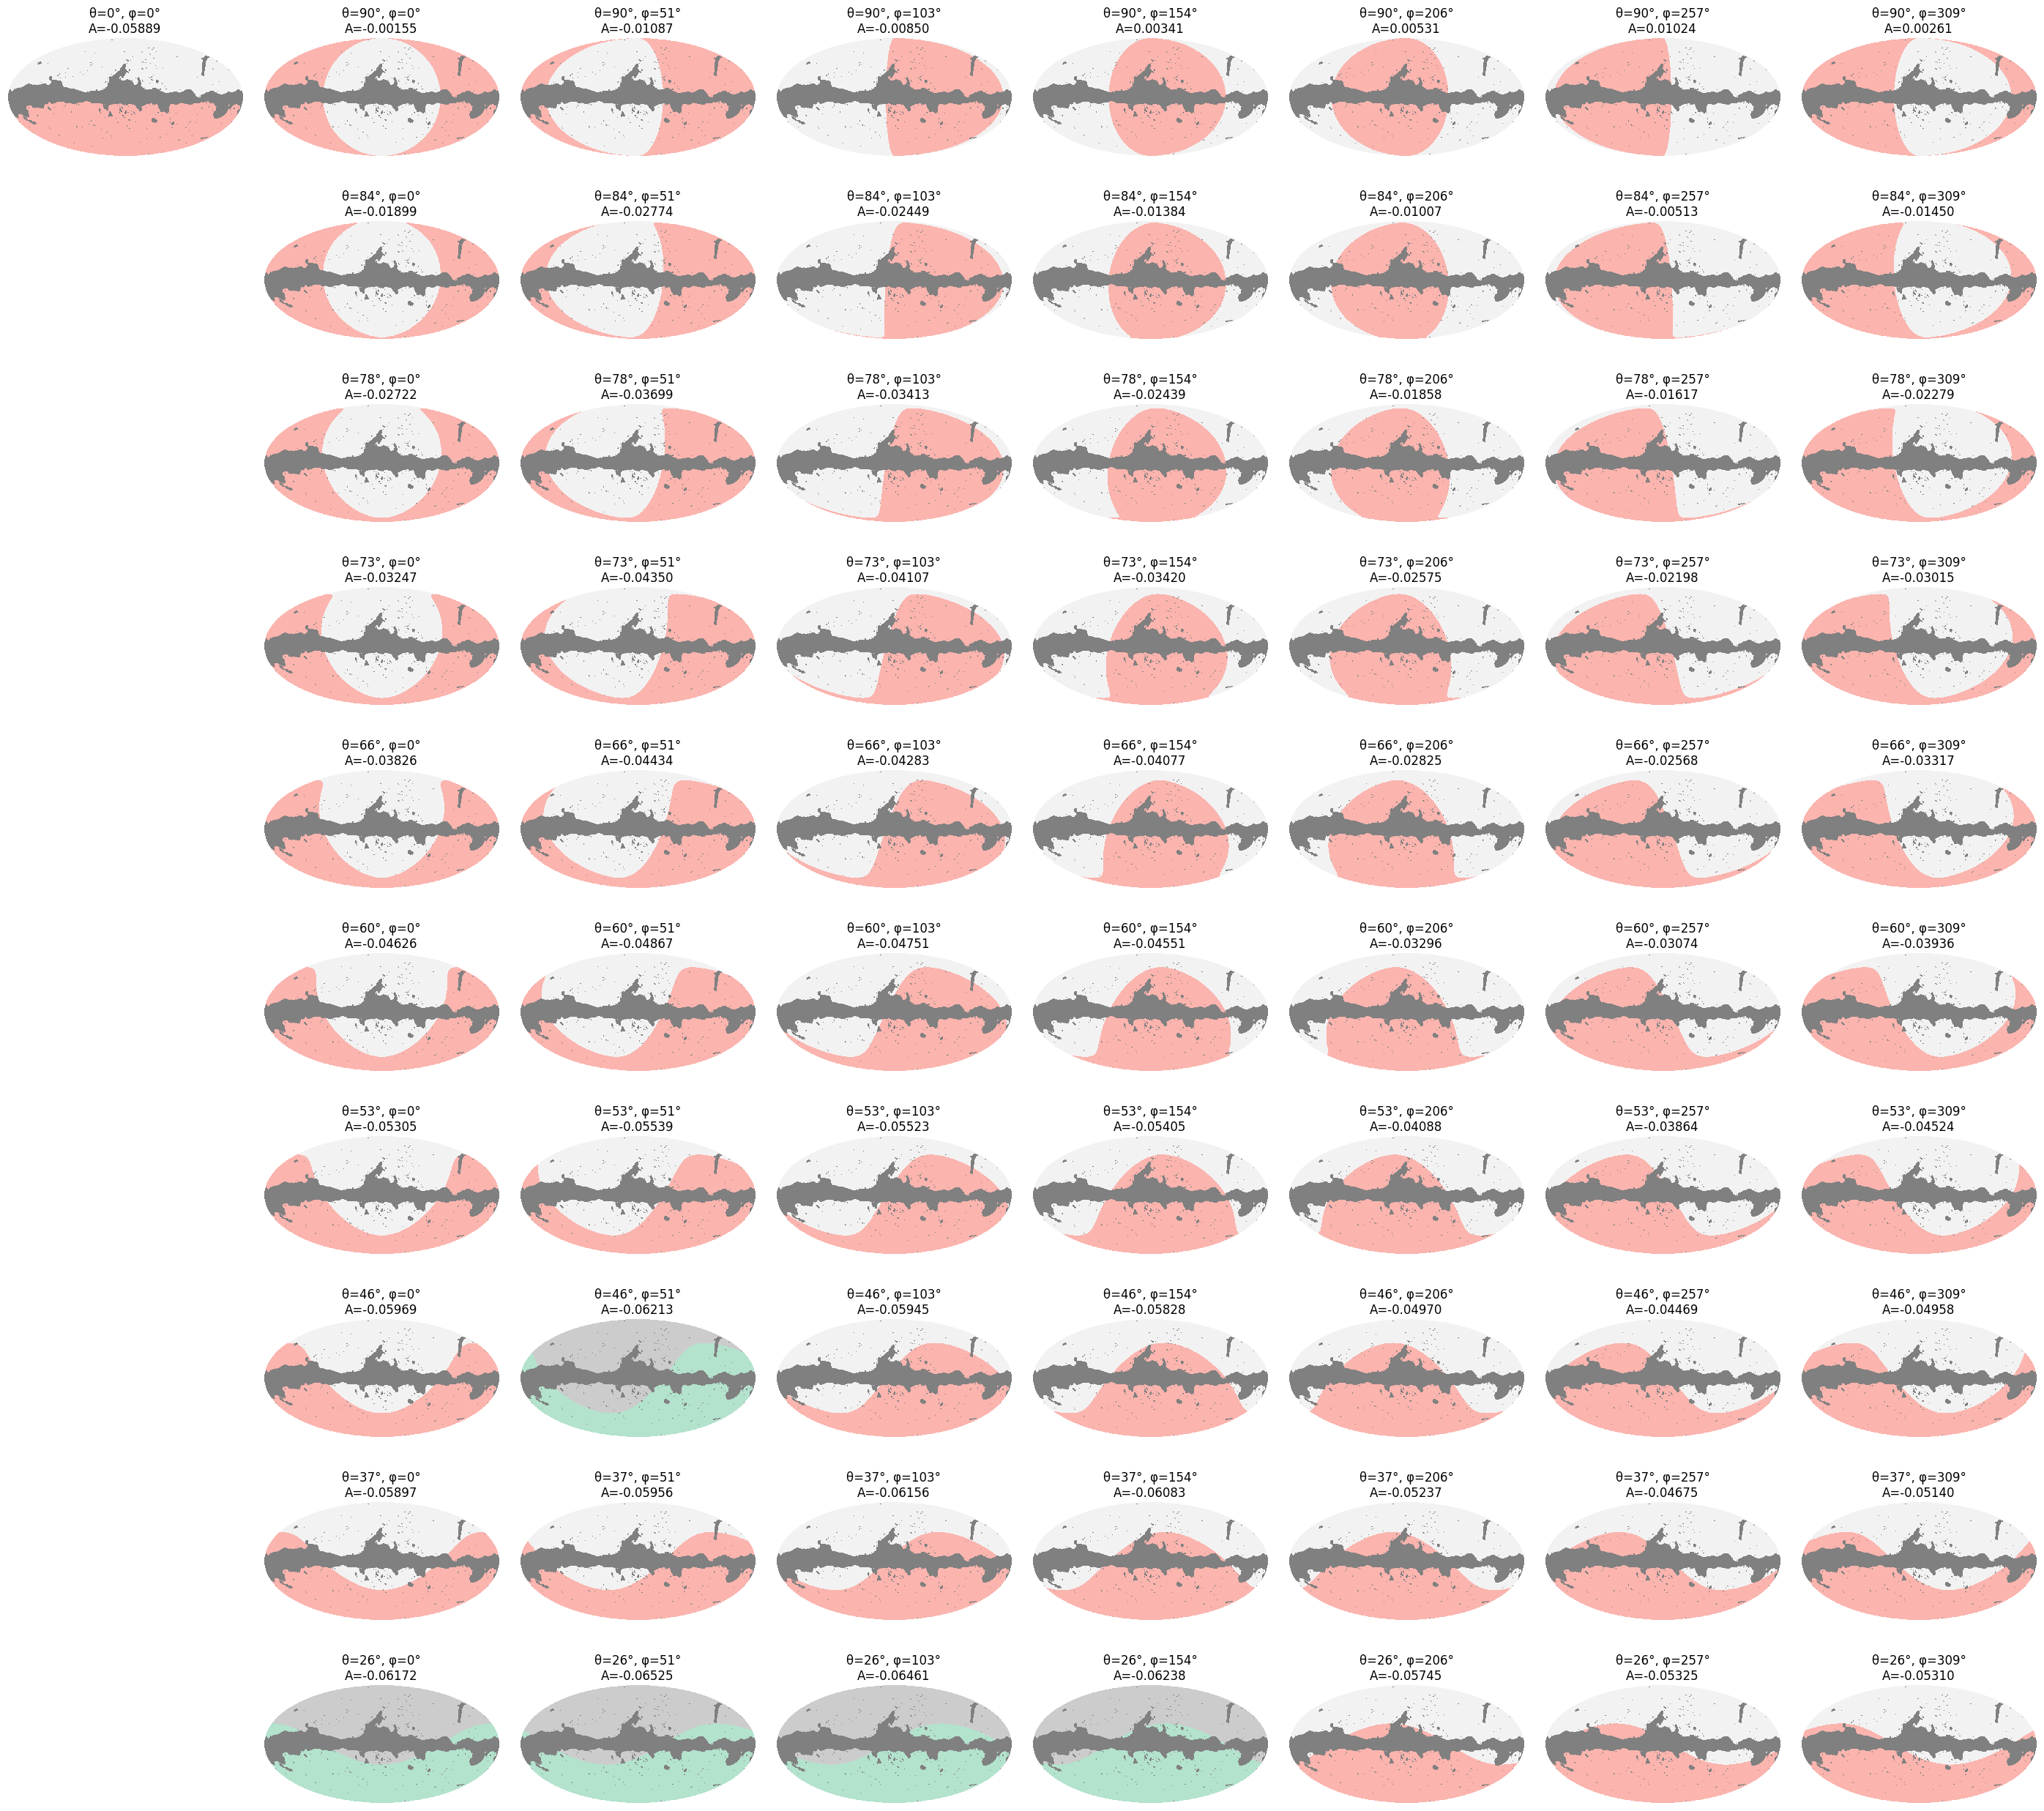

In [9]:
asimetria_T, theta_T, phi_T = FASES_LUNA(mT, mask, 10, 7, 2048)

/tmp/ipykernel_632/2402681874.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


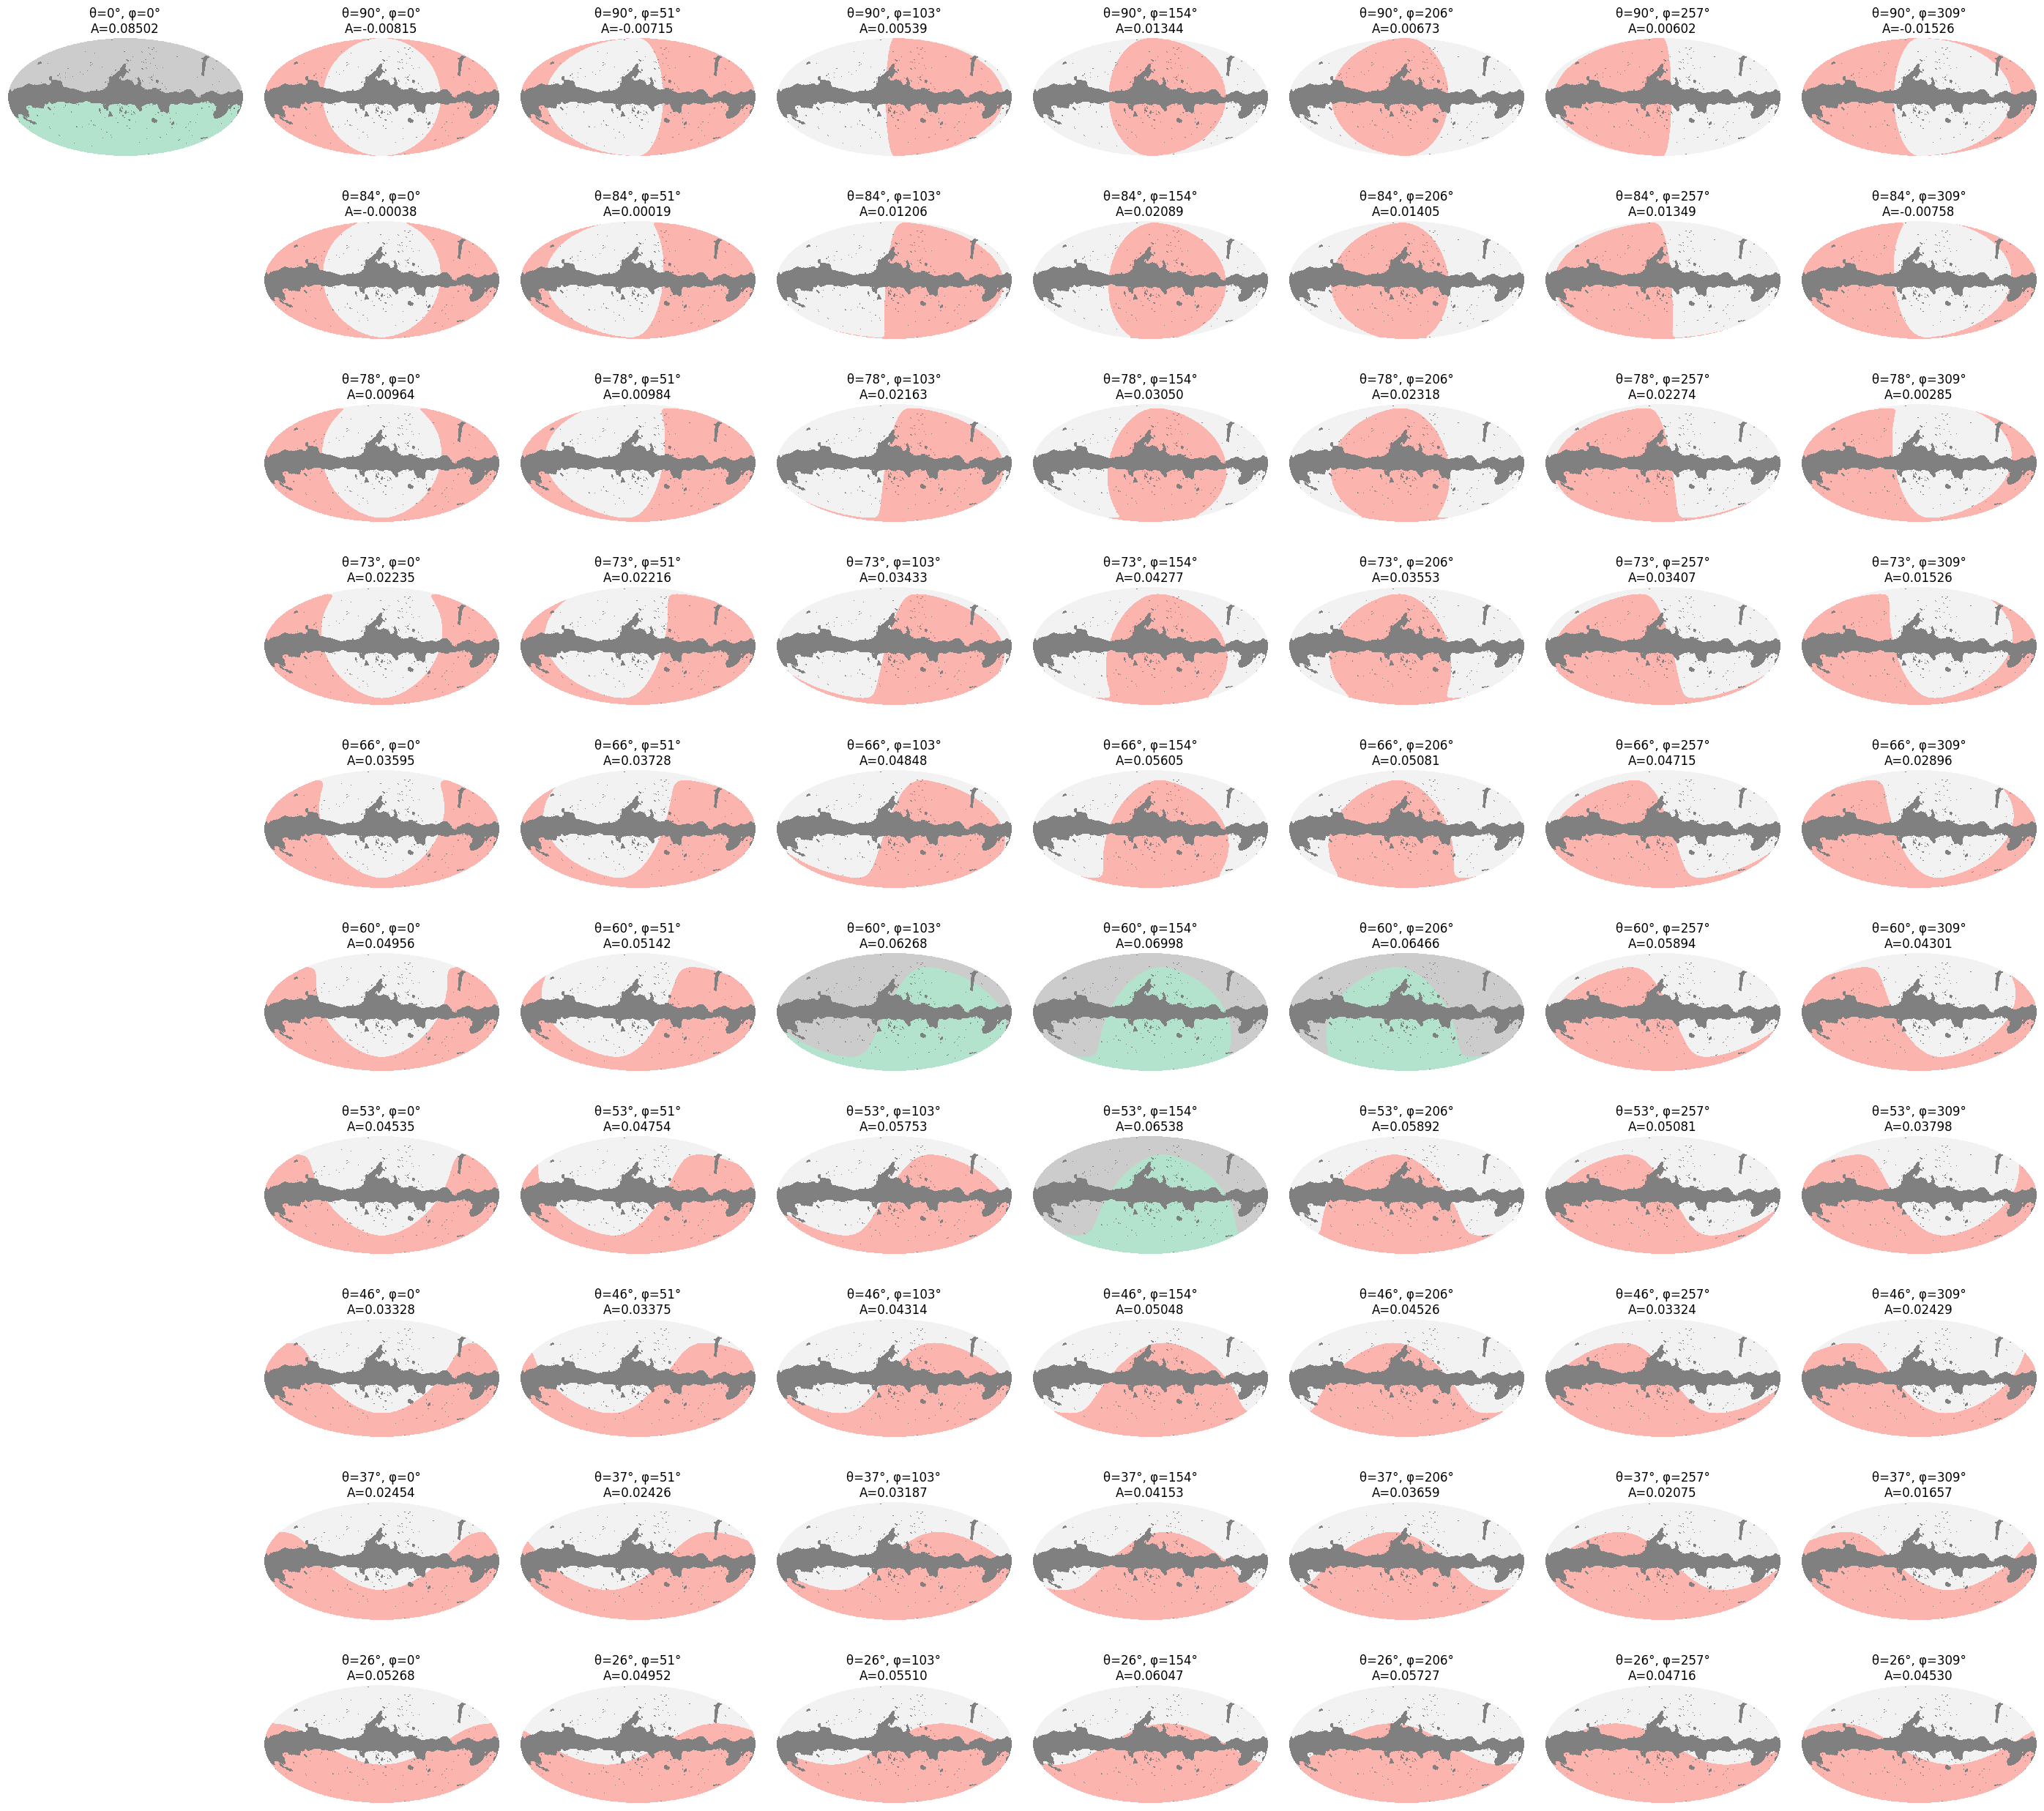

In [10]:
asimetria_Q, theta_Q, phi_Q = FASES_LUNA(mQ, mask, 10, 7, 2048)

/tmp/ipykernel_632/2402681874.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


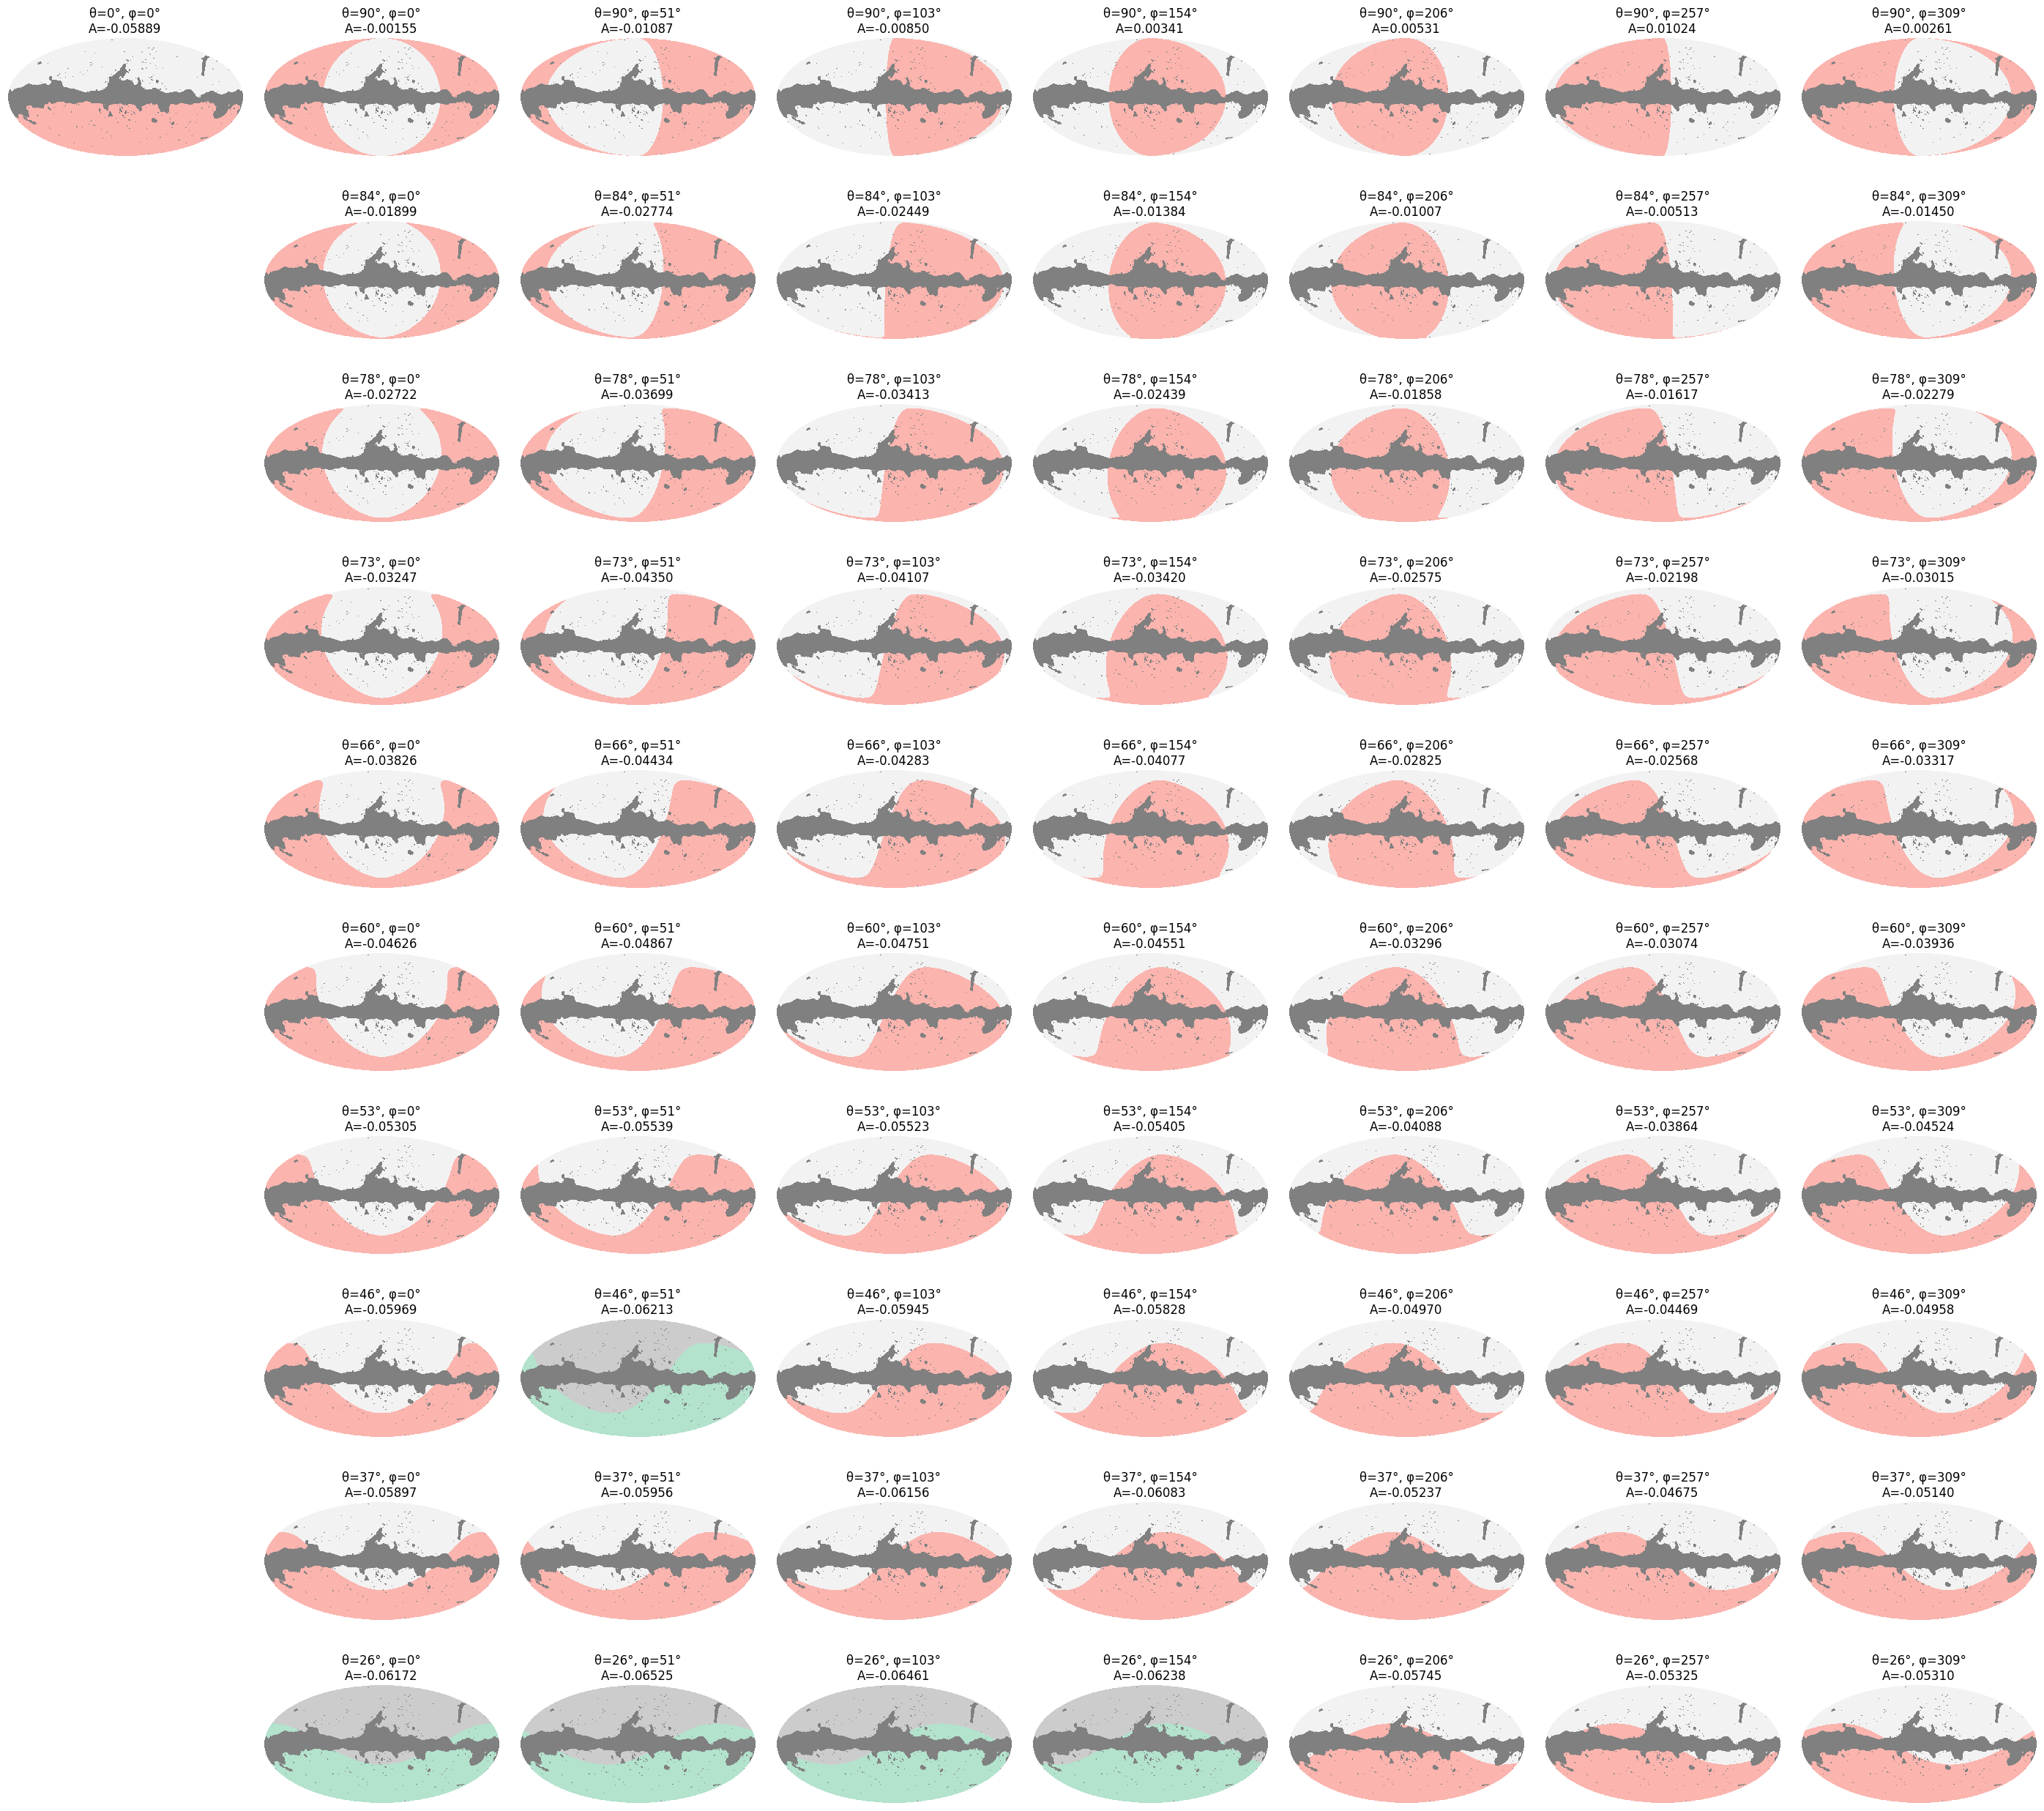

In [11]:
asimetria_U, theta_U, phi_U = FASES_LUNA(mT, mask,10, 7, 2048)

In [15]:
datos_asimetria_planos = {
    'Mapa': [f'SMICA_T - {nside_asim}']*5 + [f'SMICA_Q - {nside_asim}']*5 + [f'SMICA_U - {nside_asim}']*5,
    'Theta (°)': list(theta_T[:5]) + list(theta_Q[:5]) + list(theta_U[:5]),
    'Phi (°)': list(phi_T[:5]) + list(phi_Q[:5]) + list(phi_U[:5]),
    'Asimetría': list(asimetria_T[:5]) + list(asimetria_Q[:5]) + list(asimetria_U[:5])
}

datos_asimetria_planos = pd.DataFrame(datos_asimetria)
datos_asimetria_planos

,Mapa,Theta (°),Phi (°),Asimetría
0,SMICA_T - 2048,25.841933,0.000000,-0.061719
1,SMICA_T - 2048,45.572996,51.428571,-0.062128
2,SMICA_T - 2048,25.841933,154.285714,-0.062382
3,SMICA_T - 2048,25.841933,102.857143,-0.064606
4,SMICA_T - 2048,25.841933,51.428571,-0.065254
5,SMICA_Q - 2048,60.000000,102.857143,0.062682
6,SMICA_Q - 2048,60.000000,205.714286,0.064658
7,SMICA_Q - 2048,53.130102,154.285714,0.065384
8,SMICA_Q - 2048,60.000000,154.285714,0.069982
9,SMICA_Q - 2048,0.000000,0.000000,0.085017


Vemos nuevamente como para T y U obtenemos que la asimetría es a favor del hemisferio sur, así como para Q se da para el hemisferio norte

---

In [4]:
def ASIMETRIA_PLANO(mapa, mask_gal, nside, theta, phi, titulo,mostrar = False):
    'Obtiene diversos planos que dividen en dos el mapa de CMB.'
    'Calcula la asimetría entre dos hemisferios de este mapa, para cada plano.'

    # Obtenemos los ángulos esféricos (theta: colatitud, phi: longitud) de cada píxel
    npix = hp.nside2npix(nside)
    theta_r, phi_r = hp.pix2ang(nside, np.arange(npix))
    
    # Aplicamos la máscara al mapa (si está definida).
    mapa_cargado = hp.ma(mapa)
    if mask_gal is not None:
        mapa_cargado.mask = np.logical_not(mask_gal)

    mapa_ajustado = hp.ud_grade(mapa_cargado, nside) 
      
    # Obtenemos el vector del plano
    x = np.sin(np.radians(theta)) * np.cos(np.radians(phi))
    y = np.sin(np.radians(theta)) * np.sin(np.radians(phi))
    z = np.cos(np.radians(theta))

    n = np.array([x, y, z])
    
    # Una vez obtenido el vector del plano, obtenemos los vectores
    # de posición r tal que al hacer el producto escalar de dichos vectores
    # con el del plano obtendremos si estamos situados en el "norte" o el 
    # "sur".
    r = np.column_stack([np.sin(theta_r) * np.cos(phi_r),
                         np.sin(theta_r) * np.sin(phi_r),
                         np.cos(theta_r)])

    # Para evitar usar .compressed() todo el rato, vamos a 
    # seleccionar directamente qué pixeles son válidos tras aplicar
    # la máscara. De esta forma los cálculos son más rápidos.
    if mask_gal is not None:
        mapa_valido = mapa_ajustado.data[np.logical_not(mapa_ajustado.mask)]
        r = r[np.logical_not(mapa_ajustado.mask), :]
    else:
        mapa_valido = mapa_ajustado.data

    sigma_total = np.var(mapa_valido) 

    # Hacemos ahora el producto escalar
    prod_escalar = r @ n

    # El "norte" será donde el producto sea positivo
    norte = (prod_escalar > 0)    

    # El "sur" para los puntos que no pertenecen al norte
    sur = ~norte   

    # Obtenemos finalmente la varianza del norte y del sur
    sigma_norte = np.var(mapa_valido[norte])
    sigma_sur = np.var(mapa_valido[sur])
    asimetria = (sigma_norte - sigma_sur) / sigma_total   

    if mostrar == True:
        # Pintamos primero el mapa de CMB sin alterar sus datos.
        hp.mollview(mapa_ajustado,
                    title = f'{titulo}, región norte sombreada \nθ={theta:.1f}°, φ={phi:.1f}° | A={asimetria:.5f}',
                    cmap = 'spring',
                    hold = False)

        # Trazamos ahora la línea del plano. Para ello, usamos que r * n ha de ser cero en el plano. Despejando
        # obtenemos una función para theta dependiente de phi. Si le damos los valores desde cero hasta 2pi a 
        # phi, obtendremos la línea del plano completa
        phi_linea = np.linspace(0, 2 * np.pi, 500)
        denominador = x * np.cos(phi_linea) + y * np.sin(phi_linea)
        theta_linea = np.arctan2(-z,denominador)
        
        # Usando projplot añadimos esta línea a los datos del mapa.
        hp.projplot(theta_linea, phi_linea, color='black', linewidth=2, linestyle='-')
        
        plt.show()

    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - #
    return asimetria        


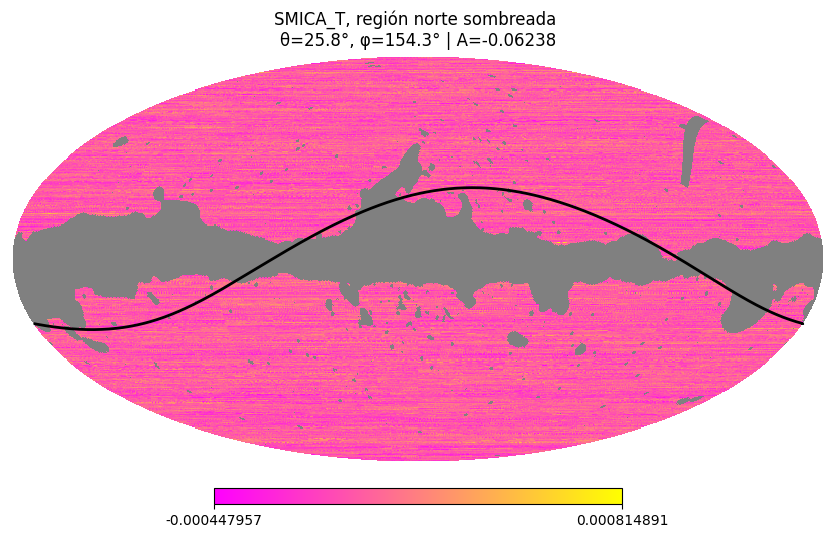

np.float32(-0.06238182)

In [5]:
ASIMETRIA_PLANO(mT, mask, 2048, 25.841933, 154.285714, 'SMICA_T', mostrar = True)